# 01 -- NLP Introduction & NLTK

welcome to the first notebook in the **NLP: From Basic to Advance**
series.

### What you'll learn in this notebook
1. what is Natural language Processing (NLP) and why it matters
2. Setting up **NLTK** (Natural Language Toolkit)
3. Downloading NLTK corpora and models
4. Tokenization (word & sntnces level)
5. Stopwods
6. Frequency Distributions
7. Exploring build-in NLTK corpora 
8. A first look at POS tagging


# 1. What is NLP?

**Natural language Processing (NLP) is a field of Artificial Intelligence that enables computers to read, understand, and genrated human language (text or speech).

**Why we use it:**
* Text is the most comman form of unstructured data (emails, reviews, articles, chats).
* We want machine to extract meanining, sentiment, structure, and intent from this text automatically.

**Where it's used:**
* Search engines, chatbots, spam filters, translation, sentiment analysis, voice assistance and much more.

We'll build these skill up notebook - starting with the fundamentals using **NLTK**, one of the oldest and most widely taught NLP libraries in python.


## 01 - NLP BASICS
===================

WHAT  : Natural Language Processing (NLP) is the field of AI that lets computers
        read, understand, and generate human language (text/speech).

WHERE : Chatbots, Google Search, Gmail spam filter, Alexa/Siri, translation
        apps (Google Translate), auto-complete, resume screening, review analysis.

WHY   : Human language is unstructured & ambiguous. NLP converts it into a
        structured form a machine can compute on (numbers/vectors).

This file gives a bird's-eye view of the full NLP pipeline you'll learn
in this repo, step by step.



# 2. Installing NLTK

if you don't have NLTK installed yet, run the cell below (only needs to be done once).

In [1]:
# Run this once if nltk is not already installed 
# !pip installed nltk
import nltk
print("NLTK version:", nltk.__version__)

NLTK version: 3.9.2


# 3. Downloading NLTK Data

NLTK need extra data (corpora, tokenizers, taggers) that don't ship the base package. We download them with nltk.download().

The most commonly used ones for this notebook:

* punkt - sentences/word tokenizer models
* punkt_tab - tokenizer tables (newer NLTK versions) 
* stopwords - comman stopword list per language
* average_perception_tagger - POS tagger model
* gutenberg - sample text corpus we'll explore later, it is book of libraries there are expired copy right books available 18 text required.
* brown - a classic tagged corpus 




In [4]:
import nltk

# Download required NLTK resources ( safe to re-run ; it skips if already present)
resources =[
    "punk",
    "punkt_tab",
    "stopwords",
    "averaged_perception_tagger",
    "averaged_perception_tagger_eng",
    "gutenberg",
    "brown",
]

for res in resources:
    try:
        nltk.download(res, quiet=True)
    except Exception as e:
        print(f"Could not download {res}: {e}")

        print("Downloads attempted. If any failed above, you can re-run this cell.")

[nltk_data] Error loading punk: Package 'punk' not found in index
[nltk_data] Error loading averaged_perception_tagger: Package
[nltk_data]     'averaged_perception_tagger' not found in index
[nltk_data] Error loading averaged_perception_tagger_eng: Package
[nltk_data]     'averaged_perception_tagger_eng' not found in index


# 4.Tokenization 

**Tokenization** is the process of splitting text into smaller units clled tokens-- usually words or sentences.

**Why we use it:**  Almost every NLP starts here. Models can't work with a raw string; they need it broken into discrite units first.

**Where it's used:** Search engine, chatbots, spell chckers, machine translation- literally every text pipeline.


In [ ]:
from nltk.tokenize import word_tokenize, sent_tokenize

text = """Natural Language Processing is amazing! It helps computers understand human language.
Have you ever wondered how siri or Alexa understand you? That's NLP at work."""

# ---Sentence Tokenization ---
sentences = sent_tokenize(text)
print("Numbers of sentences:", len(sentences))

for i, s in enumerate(sentences, 1):
    print(f"{i}. {s}")
    


Numberss of sentences: 4
1. Natural Language Processing is amazing!
2. It helps computers understand human language.
3. Have you ever wondered how siri or Alexa understand you?
4. That's NLP at work.


In [3]:
# --- Word Tokenization ---
words = word_tokenize(text)
print("Number of words (tokens):", len(words))
print(words)

Number of words (tokens): 30
['Natural', 'Language', 'Processing', 'is', 'amazing', '!', 'It', 'helps', 'computers', 'understand', 'human', 'language', '.', 'Have', 'you', 'ever', 'wondered', 'how', 'siri', 'or', 'Alexa', 'understand', 'you', '?', 'That', "'s", 'NLP', 'at', 'work', '.']


### Try it yourself
Change the `text` variable below to any paragraph you like and re-run to see how it tokenizes.

In [5]:
my_text = "Repalace this sentence with your own text to experiment!"
print(word_tokenize(my_text))


['Repalace', 'this', 'sentence', 'with', 'your', 'own', 'text', 'to', 'experiment', '!']


## 5. Stopwords

**Stopwords** are common words (like "the", "is", "and", "a") that occur frequently but usually carry little unique meaning for tasks like classification or search.

**Why we use removal:** Reduces noise and vocabulary size, often improving model speed and sometimes accuracy.

**Note:** For some tasks (e.g. sentiment analysis, where "not" matters a lot), removing stopwords can *hurt* accuracy — always think about whether it fits your task.

In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))
print("Total English stopwords:", len(stop_words))
print("Sample:", list(stop_words)[:15]) 


Total English stopwords: 198
Sample: ['out', 've', 'been', 'during', 'is', 'just', 'ours', 'before', 'he', "isn't", "wouldn't", 'shan', "they've", 'were', 'no']


In [ ]:
# Remove stopwords from our tokenized text

words_lower = [w.lower() for w in words if w.isalpha()] # keep only alphabetic tokens
filtered_words = [w for w in words_lower if w not in stop_words]

print("Before removing stopwords:", words_lower)
print()
print("After removing stopwords:", filtered_words) 



Before removing stopwords: ['natural', 'language', 'processing', 'is', 'amazing', 'it', 'helps', 'computers', 'understand', 'human', 'language', 'have', 'you', 'ever', 'wondered', 'how', 'siri', 'or', 'alexa', 'understand', 'you', 'that', 'nlp', 'at', 'work']

After removing stopwords: ['natural', 'language', 'processing', 'amazing', 'helps', 'computers', 'understand', 'human', 'language', 'ever', 'wondered', 'siri', 'alexa', 'understand', 'nlp', 'work']


## 6. Frequency Distribution

A **Frequency Distribution** counts how often each token appears in a text. This is one of the simplest but most useful ways to explore a dataset — the classic word-count / word-cloud building block.

**Where it's used:** Keyword extraction, trending topic detection, basic exploratory text analysis (EDA on text).

Most common words:
language        -> 2
understand      -> 2
natural         -> 1
processing      -> 1
amazing         -> 1
helps           -> 1
computers       -> 1
human           -> 1
ever            -> 1
wondered        -> 1


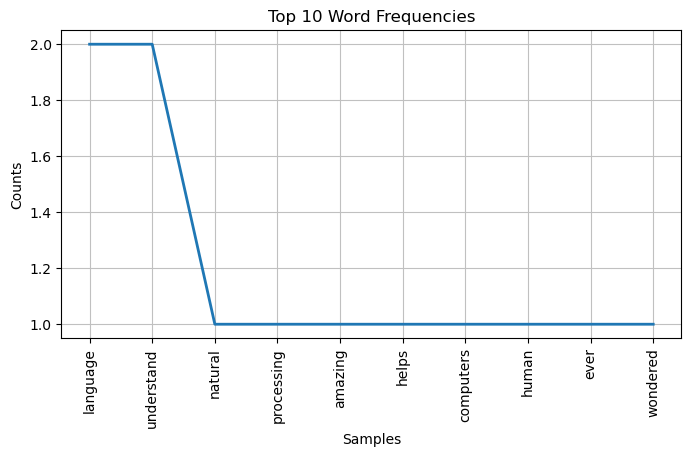

In [16]:
from nltk import FreqDist
import matplotlib.pyplot as plt

fdist = FreqDist(filtered_words)
print("Most common words:")
for word, count in fdist.most_common(10):
    print(f"{word:15s} -> {count}")

# Plot it
plt.figure(figsize=(8,4))   
fdist.plot(10, title="Top 10 Word Frequencies")
plt.show() 

## 7. Exploring a Build-in NLTK Corpus

NLTK ships with several classic text corpora. let's explore the 
**Gutenberg corpus** (public domain books) as a real dataset.

In [ ]:
from nltk.corpus import gutenberg
# list avaailable books in the coepus
print(gutenberg.fileids())  

['austen-emma.txt', 'austen-persuasion.txt', 'austen-sense.txt', 'bible-kjv.txt', 'blake-poems.txt', 'bryant-stories.txt', 'burgess-busterbrown.txt', 'carroll-alice.txt', 'chesterton-ball.txt', 'chesterton-brown.txt', 'chesterton-thursday.txt', 'edgeworth-parents.txt', 'melville-moby_dick.txt', 'milton-paradise.txt', 'shakespeare-caesar.txt', 'shakespeare-hamlet.txt', 'shakespeare-macbeth.txt', 'whitman-leaves.txt']


In [12]:
# Load one book and inspect it

sample_book = gutenberg.raw("shakespeare-hamlet.txt")

print("Total charcters:", len(sample_book))
print()
print("First 500 charchters:\n")
print(sample_book[:500])


Total charcters: 162881

First 500 charchters:

[The Tragedie of Hamlet by William Shakespeare 1599]


Actus Primus. Scoena Prima.

Enter Barnardo and Francisco two Centinels.

  Barnardo. Who's there?
  Fran. Nay answer me: Stand & vnfold
your selfe

   Bar. Long liue the King

   Fran. Barnardo?
  Bar. He

   Fran. You come most carefully vpon your houre

   Bar. 'Tis now strook twelue, get thee to bed Francisco

   Fran. For this releefe much thankes: 'Tis bitter cold,
And I am sicke at heart

   Barn. Haue you had quiet Guard?
  Fran. Not


In [17]:
# Quick word-frequency exploration on the book
book_words = word_tokenize(sample_book.lower())
book_words = [w for w in book_words if w.isalpha() and w not in stop_words]

book_fdist = FreqDist(book_words)
print("Most common words in 'Emma' (excluding stopwords):")
for word, count in book_fdist.most_common(15):
    print(f"{word:15s} -> {count}")

Most common words in 'Emma' (excluding stopwords):
ham             -> 337
lord            -> 211
haue            -> 175
king            -> 172
shall           -> 107
come            -> 104
let             -> 104
thou            -> 104
hamlet          -> 100
good            -> 98
hor             -> 95
thy             -> 90
enter           -> 85
oh              -> 81
like            -> 77


## 8. A First Look at POS Tagging

**Part-of-Speech (POS) Tagging** labels each word with its grammatical role — noun, verb, adjective, etc.

**Purpose:** Understanding sentence structure is essential for tasks like Named Entity Recognition, parsing, and grammar-aware text generation. We'll go much deeper into this in **Notebook 03**, but here's a quick preview.

In [18]:
from  nltk import pos_tag

sample_sentence = "NLTK is a powerful library for text processing."
tokens = word_tokenize(sample_sentence)
tags = pos_tag(tokens)

print(tags)

[('NLTK', 'NNP'), ('is', 'VBZ'), ('a', 'DT'), ('powerful', 'JJ'), ('library', 'NN'), ('for', 'IN'), ('text', 'NN'), ('processing', 'NN'), ('.', '.')]


**Reading the tags:** `NNP` = proper noun, `VBZ` = verb (3rd person singular), `DT` = determiner, `JJ` = adjective, `NN` = noun, `IN` = preposition. Full tag reference:

```python
import nltk
nltk.help.upenn_tagset()   # prints the full list with descriptions
```

## Summary

| Concept | What it does | Why we use it |
|---|---|---|
| Tokenization | Splits text into words/sentences | Foundation for all NLP tasks |
| Stopwords removal | Removes common low-meaning words | Reduces noise, focuses on meaningful words |
| Frequency Distribution | Counts word occurrences | Quick exploratory text analysis |
| Corpora | Pre-built text datasets | Practice & benchmarking without collecting your own data |
| POS Tagging | Labels grammatical role of words | Basis for parsing, NER, and grammar-aware tasks |

### Next up
**Notebook 02 — Text Preprocessing**: lowercasing, punctuation/number removal, stemming vs. lemmatization, regex cleaning, and building a full preprocessing pipeline function.

Let your assistant know when you're ready and it'll be built next.